In [1]:
import os
import argparse
import numpy as np
import pandas as pd
from numpy.linalg import eigh
import json  # NEW
import matplotlib.pyplot as plt  # NEW

In [2]:
# --- 现有函数之下新增两个小工具： ---
def scree_from_S(S):
    """返回降序特征值及其累计能量占比。"""
    evals = np.linalg.eigvalsh(S)      # 升序
    evals = np.clip(evals, 0.0, None)  # 数值安全
    evals = evals[::-1]                 # 降序
    total = np.sum(evals) + 1e-12
    cume = np.cumsum(evals) / total
    return evals, cume  # [L], [L]

In [3]:
def auto_choose_k(evals, cume, thresh=0.90, min_k=8, max_k=None):
    L = evals.shape[0]
    max_k = L if max_k is None else min(max_k, L)
    idx = int(np.searchsorted(cume, thresh) + 1)  # 最小满足累计能量>=阈值的位置（1-index）
    k = max(min_k, min(idx, max_k))
    return k

In [6]:
def zscore_train(a):
    m = np.nanmean(a)
    s = np.nanstd(a)
    s = 1.0 if s < 1e-12 else s
    return (a - m) / s

In [15]:
def build_xy(series, L, H):
    T = series.shape[0]
    M = T - (L + H) + 1
    X = np.stack([series[i:i+L] for i in range(M)], axis=0)     # [M, L]
    Y = np.stack([series[i+L:i+L+H] for i in range(M)], axis=0) # [M, H]
    # 去样本均值（与协方差定义一致）
    Xc = X - X.mean(axis=0, keepdims=True)
    Yc = Y - Y.mean(axis=0, keepdims=True)
    return Xc, Yc  # [M, L], [M, H]

def shrink_spd(C, alpha=1e-2):
    L = C.shape[0]
    trace = np.trace(C) / L
    return (1 - alpha) * C + alpha * trace * np.eye(L, dtype=C.dtype)

def inv_sqrt_spd(C, eps=1e-7):
    vals, vecs = eigh(C)
    vals = np.clip(vals, eps, None)
    return (vecs / np.sqrt(vals)) @ vecs.T

def pcca_Qin_from_S_and_CxxinvSqrt(S, Cxx_inv_sqrt, k):
    # S 的前 k 个特征向量（降序），得到 W_k；Q_in = W_k^T Cxx^{-1/2}，返回其转置 [L,k]
    evals, evecs = eigh(S)               # ascending
    idx = np.argsort(evals)[::-1][:k]
    U_k = evecs[:, idx]                  # [L,k]
    evals_k = evals[idx]
    Q_in = (U_k.T @ Cxx_inv_sqrt)        # [k,L]
    return Q_in.T, U_k, evals_k                        # [L,k]

In [2]:
# 在Jupyter Notebook中直接设置参数
file_path = "/home/yingch/FreDF-main/dataset/ETT-small/ETTh1.csv"  # 输入文件路径
save_dir = "/home/yingch/FreDF-main/dataset/PCCA_mats"  # 输出目录
train_ratio = 0.6
seq_len = 96
horizons = "96,192,336,720"  # 逗号分隔的预测时间步
mode = "avg"  # 或 "avg"    
alpha = 1e-2
k_dim = 96

# 将字符串参数转换为列表
H_list = [int(h) for h in horizons.split(",")]

In [3]:
os.makedirs(save_dir, exist_ok=True)
fname = os.path.splitext(os.path.basename(file_path))[0]
print(f"文件名: {fname}")
print(f"文件路径: {file_path}")
file_dir = os.path.join(save_dir, fname)
os.makedirs(file_dir, exist_ok=True)
L = seq_len
assert 1 <= k_dim <= L, "k_dim must be in [1, seq_len]"

# --- load data ---
if file_path.endswith(".csv"):
    df = pd.read_csv(file_path, header=0)
    # 丢弃全空列
    df = df.dropna(axis=1, how='all')
    # 若首列不是数值（时间戳），则去掉
    if df.shape[1] > 1 and not np.issubdtype(df.iloc[:,0].dtype, np.number):
        df = df.iloc[:, 1:]
    data = df.values
else:
    data = pd.read_excel(file_path, header=0).values

文件名: ETTh1
文件路径: /home/yingch/FreDF-main/dataset/ETT-small/ETTh1.csv


In [4]:
T_all, N = data.shape
T_train = int(T_all * train_ratio)
train = data[:T_train].astype(np.float64)

In [7]:
for c in range(N):
    train[:, c] = zscore_train(train[:, c])

In [9]:
H = 96
sum_XtX = np.zeros((L, L), dtype=np.float64)
sum_XtY = np.zeros((L, H), dtype=np.float64)
M_total = 0
for c in range(N):
    Xc, Yc = build_xy(train[:, c], L, H)  # [M, L], [M, H]
    M = Xc.shape[0]
    M_total += M
    sum_XtX += Xc.T @ Xc
    sum_XtY += Xc.T @ Yc
Cxx = sum_XtX / M_total
Cxy = sum_XtY / M_total

# 收缩与白化
Cxx = shrink_spd(Cxx, alpha=alpha)
Cxx_inv_sqrt = inv_sqrt_spd(Cxx)

# S = Cxx^{-1/2} Cxy C yx Cxx^{-1/2}
S = Cxx_inv_sqrt @ (Cxy @ Cxy.T) @ Cxx_inv_sqrt

In [10]:
print('S:', S.shape)

S: (96, 96)


In [16]:
q_mat, U_k, evals_k = pcca_Qin_from_S_and_CxxinvSqrt(S, Cxx_inv_sqrt, k=k_dim)

In [17]:
evals_k

array([4.47153615e+01, 6.89484300e+00, 6.77425167e+00, 1.47611837e+00,
       1.45603127e+00, 2.09878461e-01, 1.98133559e-01, 1.65730404e-01,
       9.16488378e-02, 9.04038928e-02, 7.23355924e-02, 7.15868233e-02,
       6.45486108e-02, 6.41055155e-02, 3.10977880e-02, 2.32034270e-02,
       1.75883815e-02, 1.75011132e-02, 1.54142708e-02, 1.47167977e-02,
       1.45970735e-02, 1.13512481e-02, 9.34147587e-03, 9.18360291e-03,
       8.88761053e-03, 8.29181209e-03, 4.81364480e-03, 4.81101605e-03,
       3.47673219e-03, 3.43304971e-03, 2.62214095e-03, 2.40843563e-03,
       1.90685415e-03, 1.87695347e-03, 1.82020851e-03, 1.78522027e-03,
       1.56651201e-03, 1.08956717e-03, 8.94281906e-04, 6.37235755e-04,
       6.05978374e-04, 4.93207339e-04, 4.27878430e-04, 3.88272613e-04,
       3.84806896e-04, 3.57435640e-04, 3.26947806e-04, 3.12605034e-04,
       3.10579094e-04, 2.71971956e-04, 2.36187674e-04, 2.15301453e-04,
       2.04236831e-04, 1.54029155e-04, 1.47707940e-04, 1.42583409e-04,
      

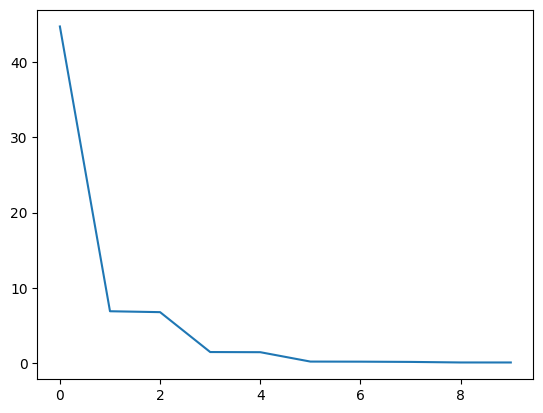

In [19]:
plt.plot(evals_k[0:10])

In [23]:
i = 100
train_data = train[i:i+L, 0]
train_data = train_data.reshape(1, 1, -1)
train_data.shape

(1, 1, 96)

In [24]:
import torch

In [26]:
Q_in = torch.from_numpy(q_mat).float()
train_data = torch.from_numpy(train_data).float()
Q_in.shape
x_out = torch.einsum('bnt,tv->bnv', train_data, Q_in)
x_out.shape
x_out = x_out.squeeze(0).numpy()
# plt.plot(x_out[0:10])


In [27]:
x_out.shape

(1, 96)

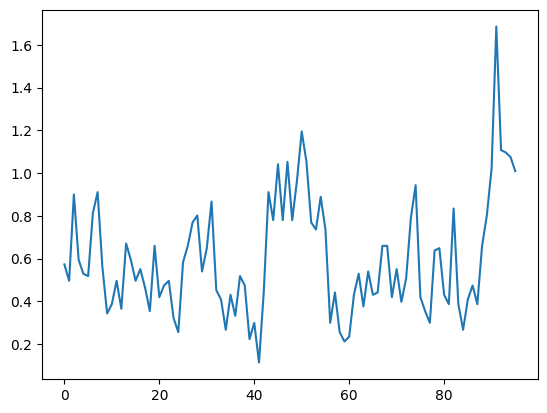

In [29]:
plt.plot(train_data.reshape(-1))

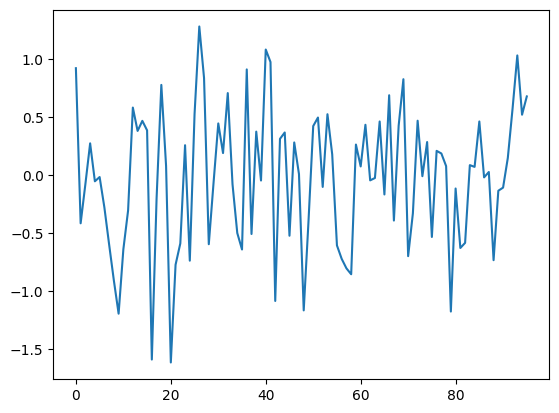

In [28]:
plt.plot(x_out.reshape(-1))

In [16]:
auto_k = True
energy_thresh=0.9
min_k=2
max_k=None
evals, cume = scree_from_S(S)
chosen_k = k_dim
if auto_k:
    chosen_k = auto_choose_k(evals, cume,
                                thresh=energy_thresh,
                                min_k=min_k, max_k=max_k)
    print(f"[auto_k] H={H}: energy@{energy_thresh:.2f} -> k={chosen_k}")

[auto_k] H=96: energy@0.90 -> k=3


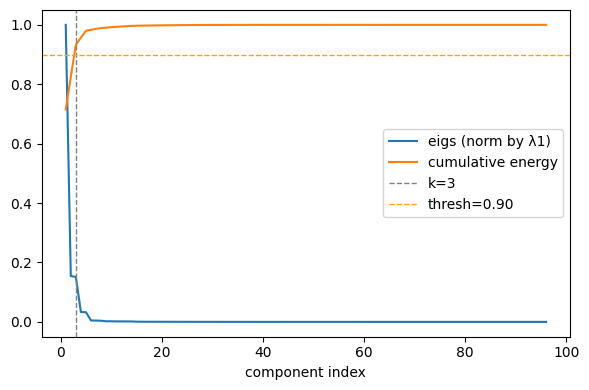

In [17]:
# 画碎石图保存
plt.figure(figsize=(6,4))
x = np.arange(1, len(evals)+1)
plt.plot(x, evals/ (evals[0]+1e-12), lw=1.5, label="eigs (norm by λ1)")
plt.plot(x, cume, lw=1.5, label="cumulative energy")
plt.axvline(chosen_k, color="gray", ls="--", lw=1.0, label=f"k={chosen_k}")
plt.axhline(energy_thresh, color="orange", ls="--", lw=1.0, label=f"thresh={energy_thresh:.2f}")
plt.xlabel("component index")
plt.legend(); plt.tight_layout()
plt.show()

In [1]:
import numpy as np

In [3]:
Q_out = np.load("/home/yingch/FreDF-main/dataset/PCCA_mats/ETTh1/ETTh1_PCCA_OUT_L96_K96_H336_svdB_avg.npy")
Q_out_new = np.load("/home/yingch/FreDF-main/dataset/PCCA_mats/ETTh1/ETTh1_PCCA_OUT_L96_K96_H336_svdB_avg_new.npy")

Q_out.shape




(336, 336)

In [2]:
Q_in_r16 = np.load("/home/yingch/FreDF-main/dataset/RRR_mats/ETTh1/ETTh1_RRR_L96_R16_H192_Qin.npy")
Q_in_r96 = np.load("/home/yingch/FreDF-main/dataset/RRR_mats/ETTh1/ETTh1_RRR_L96_R96_H192_Qin.npy")
R_r16 = np.load("/home/yingch/FreDF-main/dataset/RRR_mats/ETTh1/ETTh1_RRR_L96_R16_H192_R.npy")
R_r96 = np.load("/home/yingch/FreDF-main/dataset/RRR_mats/ETTh1/ETTh1_RRR_L96_R96_H192_R.npy")

In [3]:
Q_in_r16.shape, Q_in_r96.shape, R_r16.shape, R_r96.shape

((96, 16), (96, 96), (16, 192), (96, 192))

In [8]:
Q_in_r16 == Q_in_r96[:,:16]

array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]])

In [9]:
R_r16 == R_r96[:16,:]


array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]])